--- RESUMO ESTATÍSTICO ---


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


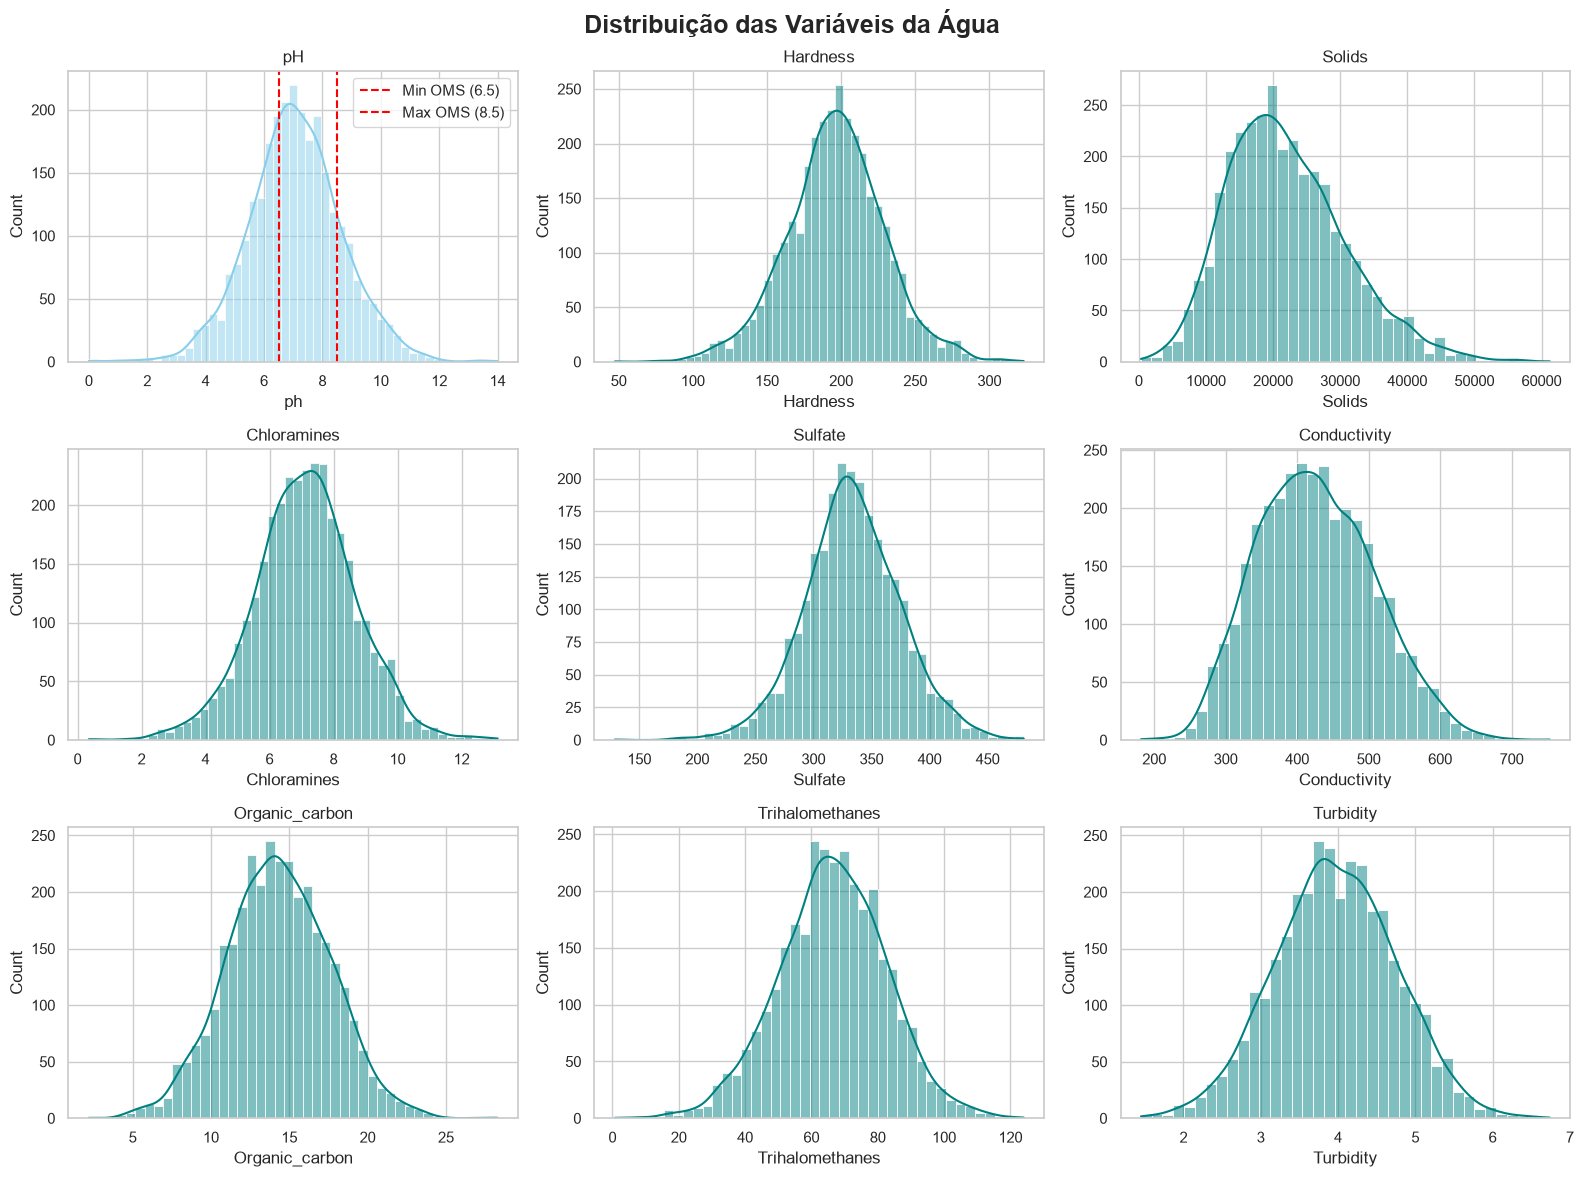

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual
sns.set_theme(style="whitegrid")

# 1. Carregando os dados
df = pd.read_csv('../datasets/water_potability.csv')

# 2. Estatística Descritiva Básica
print("--- RESUMO ESTATÍSTICO ---")
display(df.describe())

# 3. Análise Univariada: Distribuição das variáveis
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Distribuição das Variáveis da Água', fontsize=18, fontweight='bold')

# Plotando o pH separadamente para incluir as regras de negócio da OMS
sns.histplot(df['ph'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].axvline(6.5, color='red', linestyle='--', label='Min OMS (6.5)')
axes[0, 0].axvline(8.5, color='red', linestyle='--', label='Max OMS (8.5)')
axes[0, 0].legend()
axes[0, 0].set_title('pH')

# Lista das outras variáveis numéricas
cols = ['Hardness', 'Solids', 'Chloramines', 'Sulfate', 
        'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

# Loop para plotar o restante das variáveis
for i, col in enumerate(cols):
    row = (i + 1) // 3
    col_idx = (i + 1) % 3
    sns.histplot(df[col], kde=True, ax=axes[row, col_idx], color='teal')
    axes[row, col_idx].set_title(col)

plt.tight_layout()
plt.show()


--- DIAGNÓSTICO DE DADOS AUSENTES ---
Colunas com dados ausentes identificadas: ['ph', 'Sulfate', 'Trihalomethanes']



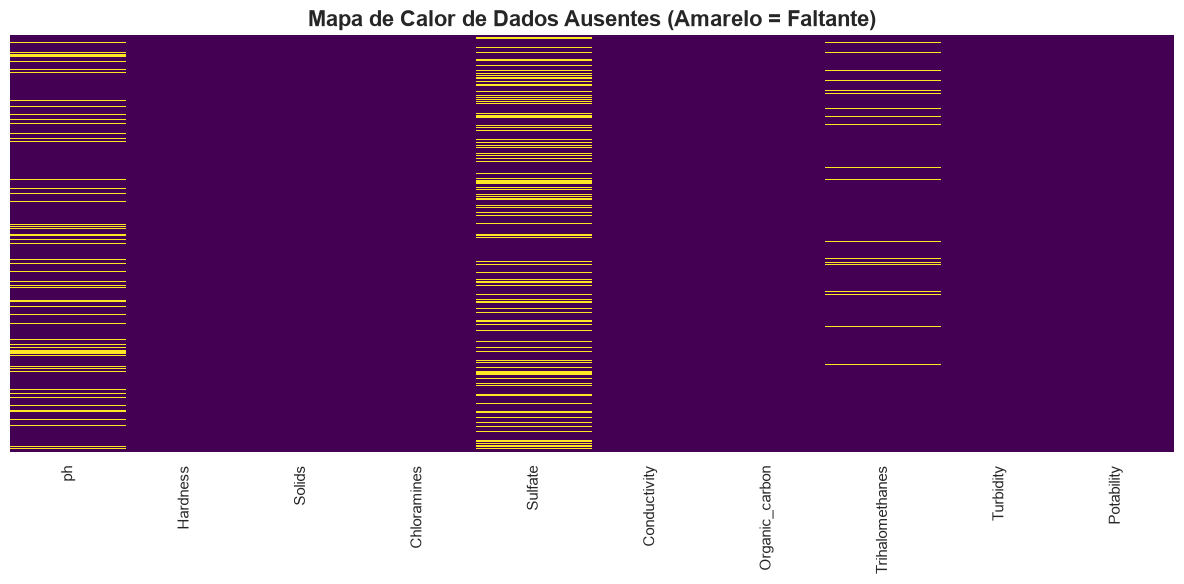

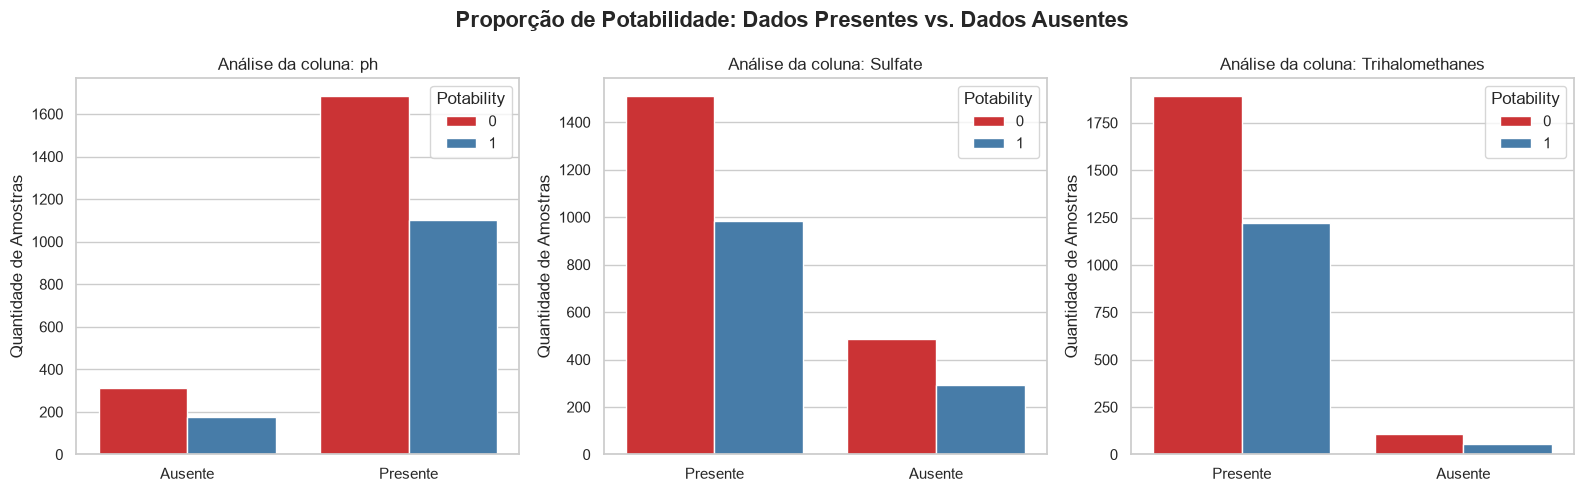


--- ANÁLISE PROPORCIONAL NUMÉRICA ---

>>> Quando 'ph' é NULO, a distribuição alvo é:


Potability
0    63.95
1    36.05
Name: proportion, dtype: float64

>>> Quando 'ph' NÃO é NULO, a distribuição alvo é:


Potability
0    60.47
1    39.53
Name: proportion, dtype: float64

--------------------------------------------------

>>> Quando 'Sulfate' é NULO, a distribuição alvo é:


...

--------------------------------------------------

>>> Quando 'Trihalomethanes' é NULO, a distribuição alvo é:


Potability
0    66.05
1    33.95
Name: proportion, dtype: float64

>>> Quando 'Trihalomethanes' NÃO é NULO, a distribuição alvo é:


Potability
0    60.73
1    39.27
Name: proportion, dtype: float64

--------------------------------------------------


In [ ]:
import numpy as np

# PARTE 2 Diagnóstico Visual e Numérico de Dados Ausentes
print("\n--- DIAGNÓSTICO DE DADOS AUSENTES ---")
missing_data = df.isnull().sum()
missing_cols = missing_data[missing_data > 0].index.tolist()

if missing_cols:
    print(f"Colunas com dados ausentes identificadas: {missing_cols}\n")
    
    # 1. Mapa de Calor (Heatmap) para encontrar padrões de ausência
    plt.figure(figsize=(12, 6))
    # O cmap='viridis' mostra roxo para dados existentes e amarelo para dados ausentes
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
    plt.title('Mapa de Calor de Dados Ausentes (Amarelo = Faltante)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # 2. Gráficos de Barras comparando Potabilidade (Ausente vs Presente)
    # Cria uma figura dinâmica dependendo de quantas colunas têm dados faltando
    fig, axes = plt.subplots(1, len(missing_cols), figsize=(16, 5))
    fig.suptitle('Proporção de Potabilidade: Dados Presentes vs. Dados Ausentes', fontsize=16, fontweight='bold')

    for i, col in enumerate(missing_cols):
        # Criamos um DataFrame temporário marcando se o valor está 'Ausente' ou 'Presente'
        df_temp = df.copy()
        df_temp['Status'] = np.where(df_temp[col].isnull(), 'Ausente', 'Presente')
        
        # Plota as barras
        sns.countplot(data=df_temp, x='Status', hue='Potability', ax=axes[i], palette='Set1')
        axes[i].set_title(f'Análise da coluna: {col}')
        axes[i].set_ylabel('Quantidade de Amostras')
        axes[i].set_xlabel('')
        
    plt.tight_layout()
    plt.show()

    # 3. Mantendo o rigor estatístico com as proporções em texto
    print("\n--- ANÁLISE PROPORCIONAL NUMÉRICA ---")
    for col in missing_cols:
        print(f"\n>>> Quando '{col}' é NULO, a distribuição alvo é:")
        display(df[df[col].isnull()]['Potability'].value_counts(normalize=True).round(4) * 100)
        
        print(f">>> Quando '{col}' NÃO é NULO, a distribuição alvo é:")
        display(df[df[col].notnull()]['Potability'].value_counts(normalize=True).round(4) * 100)
        print("-" * 50)
else:
    print("Nenhum dado ausente encontrado.")

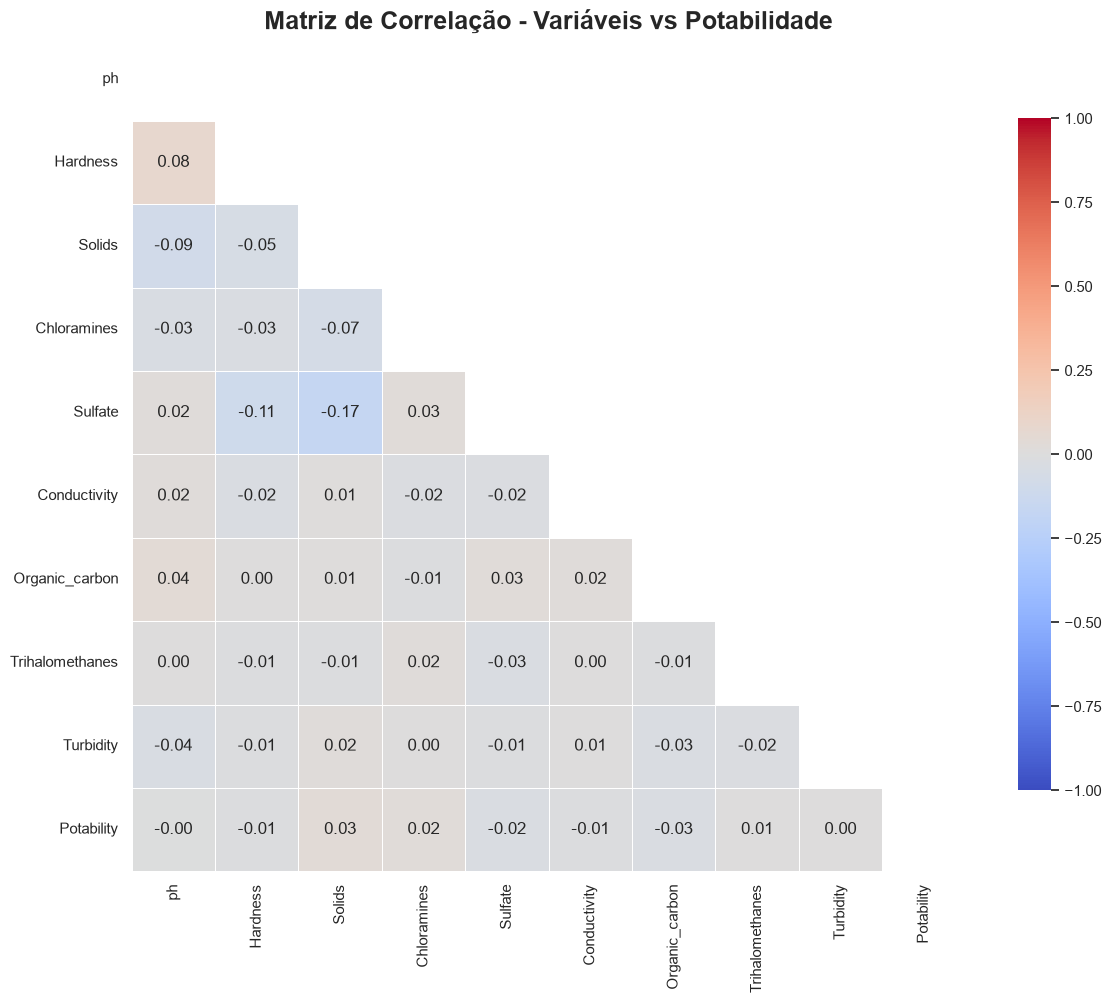

In [13]:
# PARTE 3: Matriz de Correlação e Multicolinearidade

# Configuração de estilo
sns.set_theme(style="white")

# 1. Calculando a correlação de Pearson (apenas para variáveis numéricas)
corr_matrix = df.corr()

# 2. Configurando o tamanho da figura
plt.figure(figsize=(12, 10))

# 3. Criando uma máscara para ocultar a parte superior do gráfico (evita duplicidade visual)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Desenhando o mapa de calor (Heatmap)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, 
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlação - Variáveis vs Potabilidade', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

--- TESTE DE MANN-WHITNEY U ---
H0: Não há diferença na distribuição da variável entre água potável e não potável.
H1: Há diferença estatisticamente significativa.

Tabela de Significância Estatística das Variáveis:


,Variável,Valor-P,Diferença Significativa?,Decisão
6,Organic_carbon,0.125478,Não,Falha em Rejeitar H0
2,Solids,0.133284,Não,Falha em Rejeitar H0
3,Chloramines,0.152856,Não,Falha em Rejeitar H0
4,Sulfate,0.404974,Não,Falha em Rejeitar H0
1,Hardness,0.543907,Não,Falha em Rejeitar H0
5,Conductivity,0.552283,Não,Falha em Rejeitar H0
7,Trihalomethanes,0.767153,Não,Falha em Rejeitar H0
0,ph,0.908386,Não,Falha em Rejeitar H0
8,Turbidity,0.950373,Não,Falha em Rejeitar H0


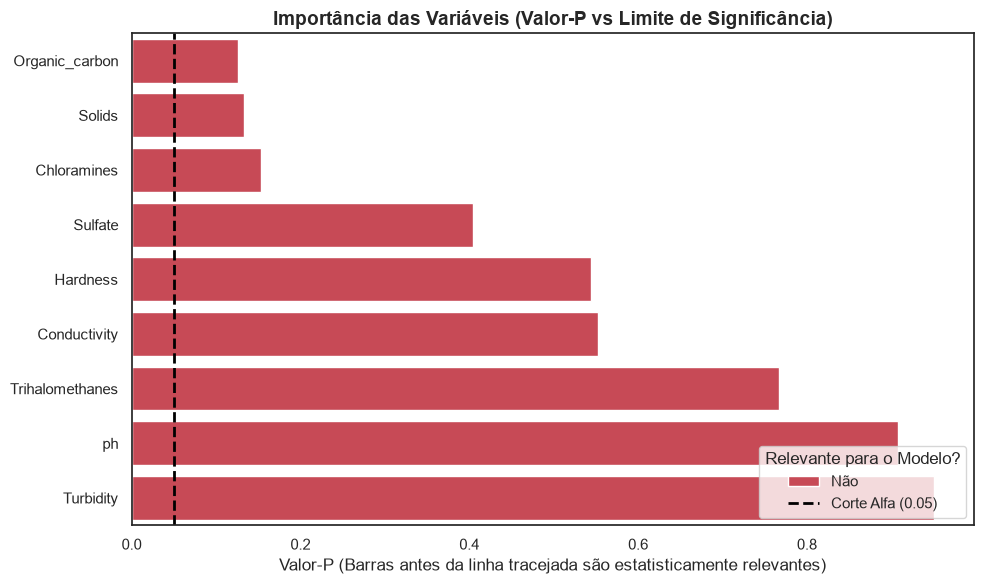

In [ ]:
# PARTE 4: Validação Estatística (Testes de Hipótese)
from scipy.stats import mannwhitneyu


print("--- TESTE DE MANN-WHITNEY U ---")
print("H0: Não há diferença na distribuição da variável entre água potável e não potável.")
print("H1: Há diferença estatisticamente significativa.\n")

# Separando os dados pelas duas classes
potavel = df[df['Potability'] == 1]
nao_potavel = df[df['Potability'] == 0]

# Lista de colunas (removendo o alvo)
features = df.columns.drop('Potability')

# Nível de significância
alfa = 0.05

# 1. Armazenando os resultados em uma lista
resultados = []

for col in features:
    # Removendo valores ausentes apenas para a execução do teste
    data_potavel = potavel[col].dropna()
    data_nao_potavel = nao_potavel[col].dropna()
    
    # Aplicando o teste estatístico
    stat, p_value = mannwhitneyu(data_potavel, data_nao_potavel, alternative='two-sided')
    
    # Avaliando a significância
    is_significant = p_value < alfa
    
    resultados.append({
        'Variável': col,
        'Valor-P': p_value,
        'Diferença Significativa?': 'Sim' if is_significant else 'Não',
        'Decisão': 'Rejeita H0' if is_significant else 'Falha em Rejeitar H0'
    })

# 2. Convertendo para DataFrame e ordenando (os mais significativos no topo)
df_resultados = pd.DataFrame(resultados).sort_values(by='Valor-P')

# 3. Exibindo a Tabela de forma nativa (sem depender do Jinja)
print("Tabela de Significância Estatística das Variáveis:")
display(df_resultados)

# 4. Criando o Gráfico de Barras para Visualização Rápida
plt.figure(figsize=(10, 6))

# Plotando as barras coloridas baseadas na significância
sns.barplot(
    data=df_resultados, 
    x='Valor-P', 
    y='Variável', 
    hue='Diferença Significativa?', 
    palette={'Sim': '#28a745', 'Não': '#dc3545'}, # Verde e Vermelho padrão Bootstrap
    dodge=False
)

# Adicionando a linha do Alfa (0.05) para referência visual
plt.axvline(alfa, color='black', linestyle='--', linewidth=2, label=f'Corte Alfa ({alfa})')

plt.title('Importância das Variáveis (Valor-P vs Limite de Significância)', fontsize=14, fontweight='bold')
plt.xlabel('Valor-P (Barras antes da linha tracejada são estatisticamente relevantes)', fontsize=12)
plt.ylabel('')
plt.legend(title='Relevante para o Modelo?', loc='lower right')
plt.tight_layout()
plt.show()

--- DISTRIBUIÇÃO DA POTABILIDADE (ALVO) ---
Não Potável (0): 1998 amostras (60.99%)
Potável (1): 1278 amostras (39.01%)
-----------------------------------------------------------------
ALERTA PARA A EQUIPE (PRÉ-PROCESSAMENTO):
Base desbalanceada! Recomenda-se aplicar técnicas de balanceamento
(como SMOTE ou Undersampling) antes do treinamento dos modelos.
-----------------------------------------------------------------


C:\Users\User\AppData\Local\Temp\ipykernel_13704\2507100330.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Potability', palette=['#dc3545', '#28a745'])


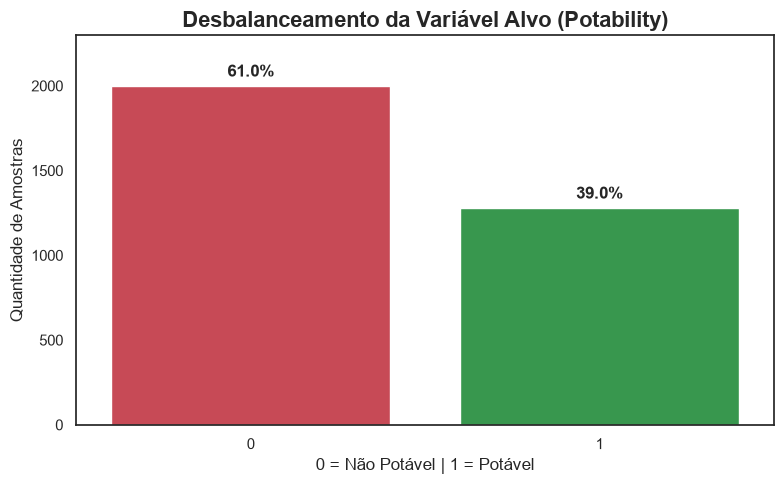

In [ ]:
# PARTE 5: Análise de Desbalanceamento da Classe Alvo
print("--- DISTRIBUIÇÃO DA POTABILIDADE (ALVO) ---")

# Calculando a contagem e a porcentagem
contagem = df['Potability'].value_counts()
porcentagem = df['Potability'].value_counts(normalize=True) * 100

# Exibindo os números no terminal
print(f"Não Potável (0): {contagem[0]} amostras ({porcentagem[0]:.2f}%)")
print(f"Potável (1): {contagem[1]} amostras ({porcentagem[1]:.2f}%)")
print("-" * 65)
print("Base desbalanceada! Recomenda-se aplicar técnicas de balanceamento")
print("(como SMOTE ou Undersampling) antes do treinamento dos modelos.")
print("-" * 65)

# Plotando o gráfico visual
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Potability', palette=['#dc3545', '#28a745'])

# Adicionando os rótulos de porcentagem em cima de cada barra
for p, perc in zip(ax.patches, porcentagem):
    ax.annotate(f'{perc:.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.title('Desbalanceamento da Variável Alvo (Potability)', fontsize=16, fontweight='bold')
plt.xlabel('0 = Não Potável | 1 = Potável', fontsize=12)
plt.ylabel('Quantidade de Amostras', fontsize=12)

# Dando um espaço extra no topo do gráfico para os números não cortarem
plt.ylim(0, max(contagem) * 1.15) 
plt.tight_layout()
plt.show()